# Experiment 5: Edge Detection using Canny and Sobel Algorithms

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow

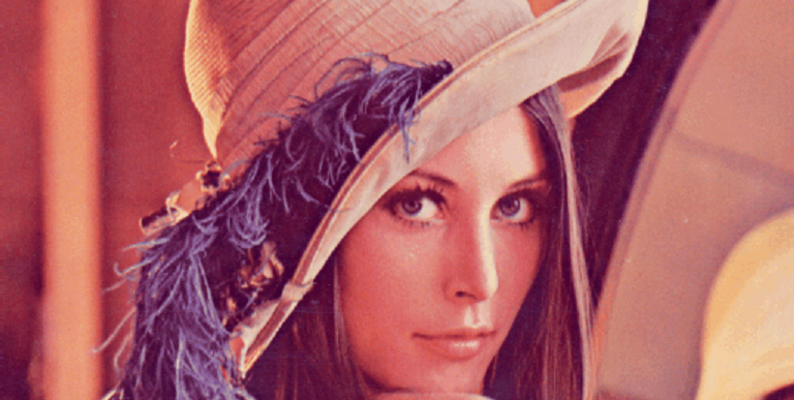

In [ ]:
image = cv2.imread('/content/drive/MyDrive/Colab Notebooks/IPCV/dataset-cover.png')
cv2_imshow(image)

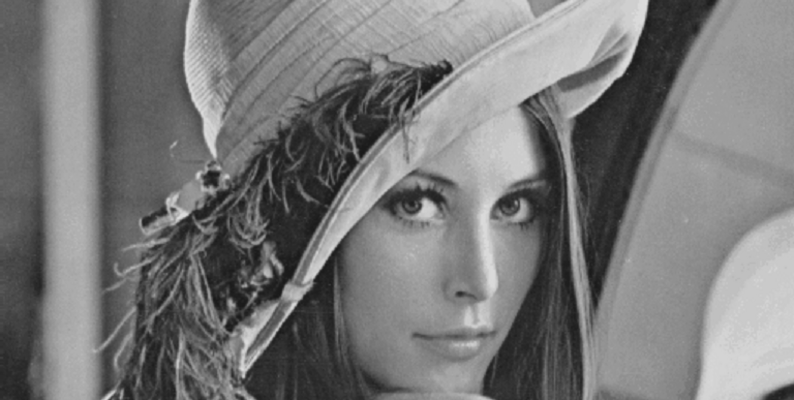

In [ ]:
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
cv2_imshow(gray)

# Canny edge detection


edges = cv2.Canny(image, threshold1, threshold2, apertureSize=3, L2gradient=False)

threshold1 = min value

threshold2  max value

threshold1 (minVal): The lower threshold for the hysteresis procedure. Gradient values below this are discarded.

threshold2 (maxVal): The upper threshold. Pixels with gradients above this are classified as "sure-edges".

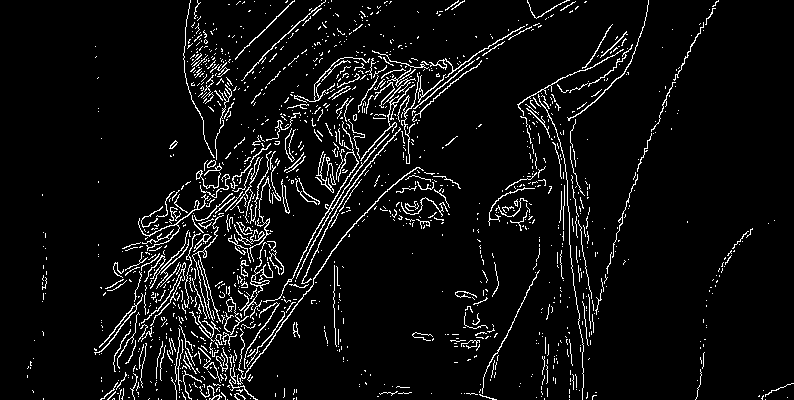

In [ ]:
canny = cv2.Canny(gray, 100, 100)
cv2_imshow(canny)

# sobel edge detection

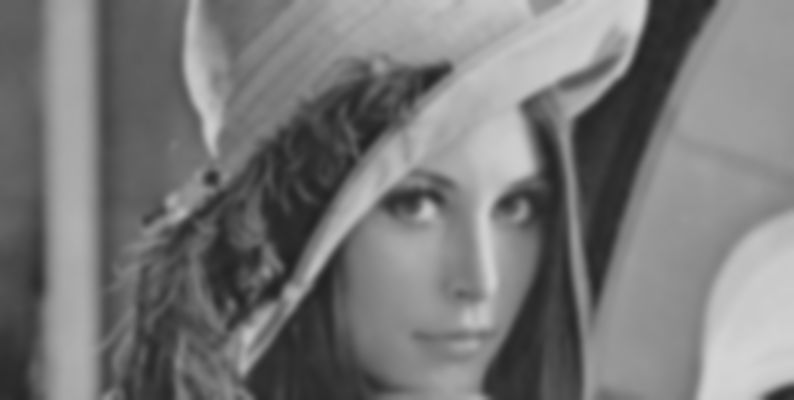

In [ ]:
blur = cv2.GaussianBlur(gray, (21, 21), 0)
cv2_imshow(blur)

In [ ]:
sobelx = cv2.Sobel(blur, cv2.CV_64F, 1, 0, ksize=5)
sobely = cv2.Sobel(blur, cv2.CV_64F, 0, 1, ksize=5)

magnitude = np.sqrt(sobelx**2 + sobely**2)

The full signature for cv2.normalize is typically cv2.normalize(src, dst, alpha, beta, norm_type, dtype).

src: This is your input array, which is sobel_magnitude in our case.

dst: This is the output array. If you provide None (as in the original code), OpenCV creates a new array to store the normalized result. If you provide an array here, the results will be written into that array.

alpha: This specifies the minimum value for the normalized range.

beta: This specifies the maximum value for the normalized range.

norm_type: This defines the type of normalization (e.g., cv2.NORM_MINMAX).

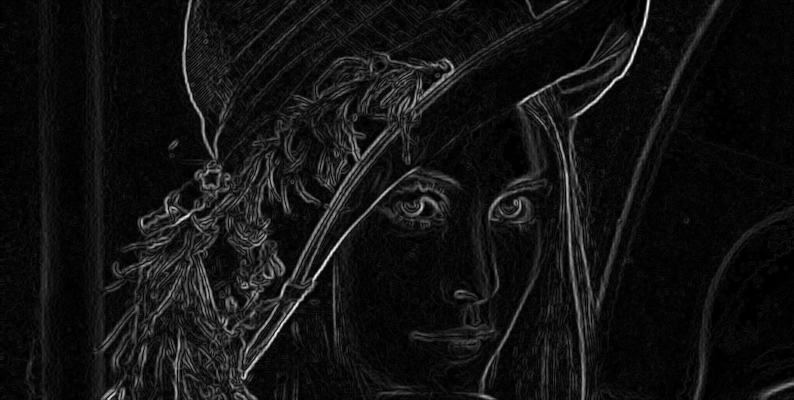

In [ ]:
# Define Sobel kernels
sobel_x = np.array([[-1, 0, 1],
                    [-2, 0, 2],
                    [-1, 0, 1]])

sobel_y = np.array([[-1, -2, -1],
                    [0, 0, 0],
                    [1, 2, 1]])

# Get image dimensions
h, w = gray.shape

# Initialize gradient arrays
gradient_x = np.zeros_like(gray, dtype=float)
gradient_y = np.zeros_like(gray, dtype=float)

# Apply convolution manually
# Pad the image to handle borders. We'll use 'edge' padding.
padded_gray = np.pad(gray, 1, mode='edge')

for i in range(1, h + 1):
    for j in range(1, w + 1):
        # Extract 3x3 region
        region = padded_gray[i-1:i+2, j-1:j+2]

        # Convolve with Sobel kernels
        gx = np.sum(region * sobel_x)
        gy = np.sum(region * sobel_y)

        gradient_x[i-1, j-1] = gx
        gradient_y[i-1, j-1] = gy

# Calculate gradient magnitude
manual_sobel_magnitude = np.sqrt(gradient_x**2 + gradient_y**2)

# Normalize the magnitude for display
manual_sobel_magnitude = cv2.normalize(manual_sobel_magnitude, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

cv2_imshow(manual_sobel_magnitude)


(np.float64(-0.5), np.float64(793.5), np.float64(399.5), np.float64(-0.5))

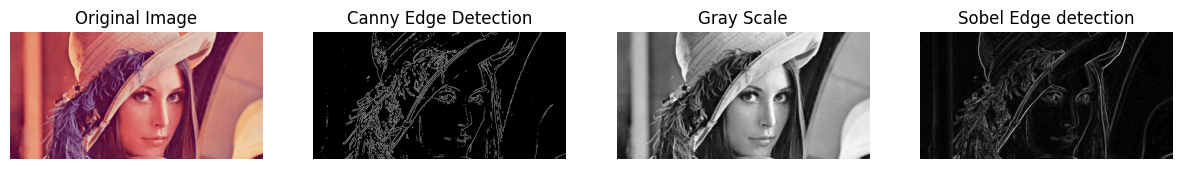

In [ ]:
plt.figure(figsize=(15,8))

plt.subplot(1,4,1)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title('Original Image')
plt.axis('off')

plt.subplot(1,4,2)
plt.imshow(canny, cmap='gray')
plt.title('Canny Edge Detection')
plt.axis('off')

plt.subplot(1,4,3)
plt.imshow(gray, cmap='gray')
plt.title('Gray Scale')
plt.axis('off')

plt.subplot(1,4,4)
plt.imshow(manual_sobel_magnitude, cmap='gray')
plt.title('Sobel Edge detection')
plt.axis('off')

This experiment successfully applied and compared Canny and Sobel edge detection methods on an image. Canny, a multi-stage approach, detected a wide range of edges, while Sobel, using kernels for gradient calculation, highlighted edges based on intensity changes. Both demonstrated effective edge identification with distinct characteristics.